# Reproduce the `squidpy.datasets.cells` dataset

In this notebook, we will reproduce the creation of the `squidpy.datasets.cells` dataset from raw data. It's a real but minimal dataset used for testing and demonstration purposes in the Squidpy library.

First, we download the raw data of the [Xenium Prime Cervical Cancer FFPE dataset from 10x Genomics](https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-cervical-cancer):

```
# download raw data
curl -O https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_outs.zip
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_he_image.ome.tif
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_he_imagealignment.csv
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_gene_panel.json

# prepare files for spatialdata-io ingestion
unzip Xenium_Prime_Cervical_Cancer_FFPE_outs.zip -d Xenium_Prime_Cervical_Cancer_FFPE_outs
mv Xenium_Prime_Cervical_Cancer_FFPE_he_image.ome.tif Xenium_Prime_Cervical_Cancer_FFPE_outs/
mv Xenium_Prime_Cervical_Cancer_FFPE_he_imagealignment.csv Xenium_Prime_Cervical_Cancer_FFPE_outs/
mv Xenium_Prime_Cervical_Cancer_FFPE_gene_panel.json Xenium_Prime_Cervical_Cancer_FFPE_outs/
```

In [ ]:
import spatialdata as sd
from spatialdata import rasterize, get_extent

import spatialdata_io as sdio 
import spatialdata_plot as sdp 
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from spatialdata.transformations import get_transformation
from spatialdata.models import Image2DModel, Labels2DModel

## 1) Create `SpatialData` object from raw data

We first ingest the entire data and will then gradually process it.

In [84]:
sdata = sdio.xenium(
    "Xenium_Prime_Cervical_Cancer_FFPE_outs",
    image_models_kwargs={"scale_factors": [2]},
    labels_models_kwargs={"scale_factors": [2]},
)
sdata

SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 46545, 38219), (3, 23272, 19109)
│     └── 'morphology_focus': DataTree[cyx] (4, 51205, 54125), (4, 25602, 27062)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (51205, 54125), (25602, 27062)
│     └── 'nucleus_labels': DataTree[yx] (51205, 54125), (25602, 27062)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (840387, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (839632, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (840387, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

Let's first visualise the H&E image. If we zoom in, we can spot a tiny piece of tissue
that detached from the rest but is still within the main capture area. That probably
means it was still processed exactly the same as the rest of the tissue. The code below
draws a red box around the detached piece of tissue.

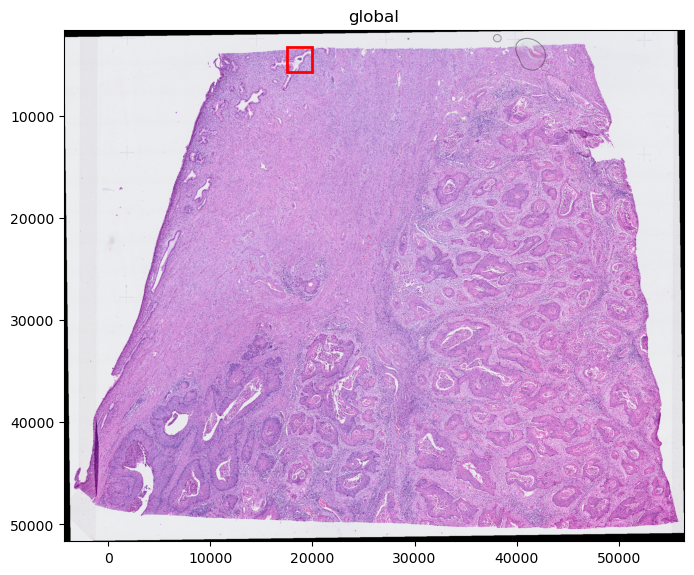

In [85]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8, 8))

(
    sdata
    .pl.render_images("he_image")
    .pl.show(ax=ax)
)

ax.add_patch(
    Rectangle(
        (17_500, 3_250),
        2_500,
        2_500,
        edgecolor="red",
        facecolor="none",
        linewidth=2)
)

Now let's subset the `SpatialData` object to only that tiny piece of tissue.

In [86]:
cropped = sdata.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[18_480, 4_330],
    max_coordinate=[19_020, 4_760],
    target_coordinate_system="global",
    filter_table=True,
)

In [87]:
cropped

SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [88]:
# 1st write for performance in downstream operations
cropped.write("cells_tmp.zarr", overwrite=True)
cropped = sd.read_zarr("cells_tmp.zarr")

We can see that our crop worked successfully and the resulting `SpatialData` object only
contains the tissue piece that we wanted. However, we can also see in the H&E image,
that it doesn't natively exist in the same pixel space as the morphology focus image due
to the black borders around it, hinting at a rotation.

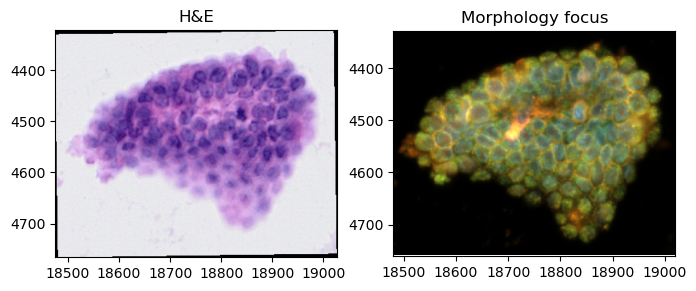

In [89]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

(
    cropped
    .pl.render_images("he_image")
    .pl.show(ax=axs[0], title="H&E")
)

(
    cropped
    .pl.render_images("morphology_focus")
    .pl.show(ax=axs[1], title="Morphology focus")
)

We can confirm this with the `get_transformation` function.

In [90]:
get_transformation(cropped["he_image"], "global")

Sequence 
    Translation (c, y, x)
        [    0. 17641. 36123.]
    Affine (c, y, x -> c, x, y)
        [1. 0. 0. 0.]
        [ 0.00000000e+00  1.28987110e+00 -1.72213367e-02 -3.65155386e+03]
        [ 0.00000000e+00 -1.72213367e-02 -1.28987110e+00  5.16637333e+04]
        [0. 0. 0. 1.]

To make downstream processing easier, we now apply this transformation by rasterizing the image into pixel space.

In [91]:
# get reference size to rasterize the H&E into
morph = cropped.images["morphology_focus"]
morph_extent = get_extent(morph, coordinate_system="global")
xmin, xmax = morph_extent["x"]
ymin, ymax = morph_extent["y"]

# morphology pitch = pixels per µm along each axis
# 1.0 here, but compute it to stay safe
morph_top = morph["scale0"].image
ny, nx = morph_top.sizes["y"], morph_top.sizes["x"]
px_per_um_x = nx / (xmax - xmin)
px_per_um_y = ny / (ymax - ymin)

he_aligned = rasterize(
    cropped.images["he_image"],
    axes=("x", "y"),
    min_coordinate=[xmin, ymin],
    max_coordinate=[xmax, ymax],
    target_coordinate_system="global",
    target_unit_to_pixels=px_per_um_x,
)

# rasterize drops the channel names, so we carry them over from the source H&E
he_channels = cropped.images["he_image"]["scale0"]["image"].coords["c"].values.tolist()

cropped.images["he_aligned"] = Image2DModel.parse(
    he_aligned,
    c_coords=he_channels,
    chunks=(1, 256, 256),
    scale_factors=[2],
)

Overlaying the `he_aligned` on top of the original `he_image` shows us which parts of
the image were lost in that process - nothing important in this case.

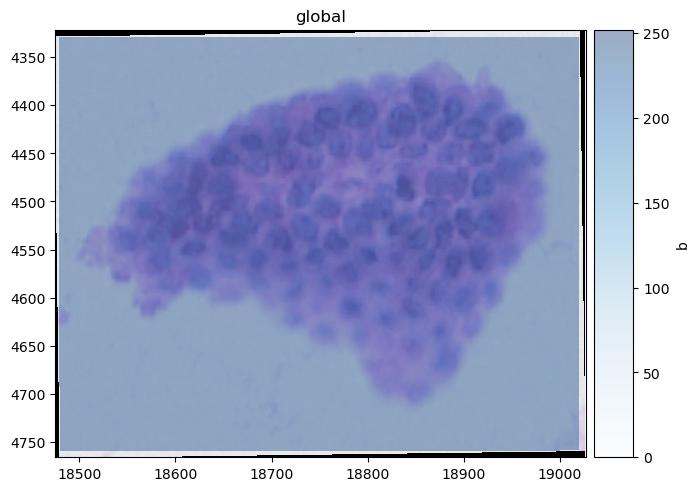

In [92]:
(
    cropped
    .pl.render_images("he_image")
    .pl.render_images("he_aligned", alpha=0.4, channel="b", cmap="Blues")
    .pl.show()
)

Inspecting the images directly also confirms that the new `he_aligned` now has the exact
same pixel dimensions as the morphology focus image.

In [93]:
cropped

SpatialData object, with associated Zarr store: ./cells_tmp.zarr
├── Images
│     ├── 'he_aligned': DataTree[cyx] (3, 430, 540), (3, 215, 270)
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_aligned (Images), he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)
with the following Dask-backed elements no

The cell and nucleus segmentation masks look mostly correct - they're slightly shifted
because the H&E image in a Xenium experiment is acquired after the actual Xenium process.

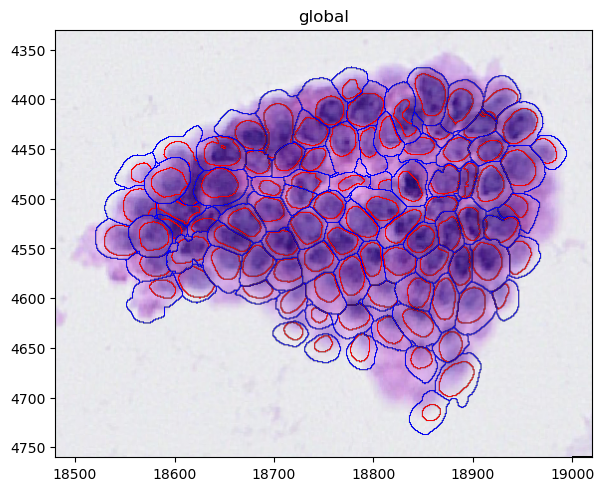

In [94]:
(
    cropped
    .pl.render_images("he_aligned")
    .pl.render_labels("nucleus_labels", color="red", outline_alpha=1, fill_alpha=0)
    .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0)
    .pl.show()
)

The `morphology_focus` image allows us to inspect this more cleanly.

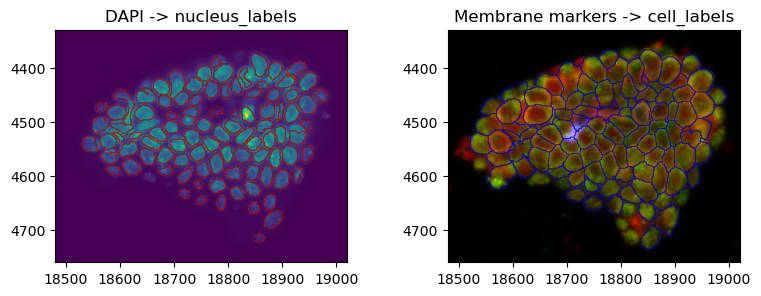

In [95]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

(
    cropped
    .pl.render_images("morphology_focus", channel="DAPI", colorbar=False)
    .pl.render_labels("nucleus_labels", color="red", outline_alpha=1, fill_alpha=0)
    # .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0)
    .pl.show(ax=axs[0], title="DAPI -> nucleus_labels")
)

(
    cropped
    .pl.render_images("morphology_focus", channel=["ATP1A1/CD45/E-Cadherin", "18S", "AlphaSMA/Vimentin"])
    # .pl.render_labels("nucleus_labels", color="red", outline_alpha=1, fill_alpha=0)
    .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0)
    .pl.show(ax=axs[1], title="Membrane markers -> cell_labels")
)

plt.tight_layout()

Let's verify that the data contains transcripts.

In [96]:
# Let's first identify a gene for which we expect a lot of transcripts.
cropped["table"].to_df().var(axis=0).sort_values()

ZNF829      0.000000
ZNF8        0.000000
ZNF346      0.000000
ZNF408      0.000000
ZNF410      0.000000
             ...    
SLC40A1     3.128346
EEF1G       3.622970
CXCL2       4.773393
THSD4       6.505262
MUC5B      11.771334
Length: 5101, dtype: float32

Let's now create a tissue mask using simple `skimage` thresholding. We'll use the `morphology_focus` 
image here because it provides a cleaner signal.

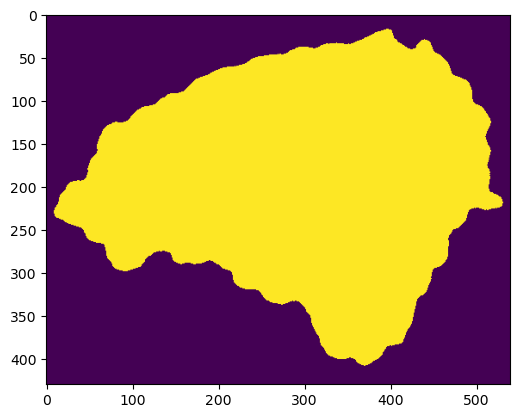

In [97]:
# 1) max-project the morphology focus to get a better view of the cell labels
morph = cropped.images["morphology_focus"]["scale0"]["image"]
image = morph.max(dim="c").compute()  

# 2) create raw mask
thresh = 180  # eyeballed, but could be computed with Otsu or similar
binary = image > thresh

# 3) prettify mask
from skimage.morphology import (
    binary_closing, remove_small_objects, remove_small_holes, disk, binary_opening
)
binary = binary_closing(binary, disk(5))     
binary = remove_small_holes(binary, area_threshold=2_000) 
binary = remove_small_objects(binary, min_size=500)
binary = binary_opening(binary, disk(5))

plt.imshow(binary)

In [98]:
# 4) add back to SpatialData object
cropped.labels["tissue_labels"] = Labels2DModel.parse(
    binary.astype("uint8"),
    transformations=get_transformation(cropped.images["morphology_focus"], get_all=True),
    scale_factors=[2],
)

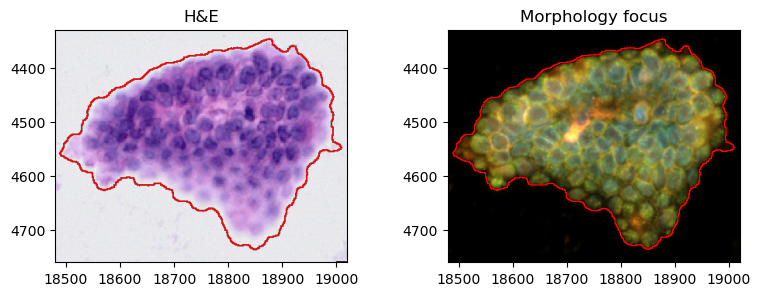

In [99]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

(
    cropped
    .pl.render_images("he_aligned")
    .pl.render_labels("tissue_labels", color="red", outline_alpha=1, fill_alpha=0, contour_px=5)
    .pl.show(ax=axs[0], title="H&E")
)

(
    cropped
    .pl.render_images("morphology_focus")
    .pl.render_labels("tissue_labels", color="red", outline_alpha=1, fill_alpha=0, contour_px=5)
    .pl.show(ax=axs[1], title="Morphology focus")
)

plt.tight_layout()

In [100]:
cropped.write("cells.zarr", overwrite=True)
cropped = sd.read_zarr("cells.zarr")

In [101]:
cropped

SpatialData object, with associated Zarr store: ./cells.zarr
├── Images
│     ├── 'he_aligned': DataTree[cyx] (3, 430, 540), (3, 215, 270)
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     ├── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'tissue_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_aligned (Images), he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), tissue_labels (Labels), transcripts (Points), cell_boundari

Above we can see the full resulting dataset which we'll provide as `cells` via `spatialdata.datasets`.

It's a deliberately tiny (94-cell) but structurally complete SpatialData object derived from real data. It is small enough to ship and load instantly, yet contains at least one element of every kind plus the awkward edge cases that exercise real code paths. It covers the following use cases:

- All five element types in one object: Images, Labels, Points, Shapes, Tables.
- Multiscale pyramids (DataTree) on every raster element, so multiscale read/render/query logic is hit.
- Multi-channel + named channel coordinates (4-channel morphology) and RGB (3-channel H&E) imagery.
- Lazy, dask-backed points (`<Delayed>` length) with 3D coordinates alongside 2D rasters/shapes for mixed dimensionality.
- Categorical point feature (feature_name) → renders/filters by gene.
- Non-trivial transformations: `he_image` still carries its affine+translation `Sequence` as a lazy coordinate transformation, next to `he_aligned`, the same image after that transformation has been applied (rasterized) into pixel space, so both coordinate-system and rasterize/alignment code paths are represented.
- Table <-> region annotation linking an AnnData to the `cell_labels` label instances via region/instance keys (with a matching `cell_id` column that also bridges to the `cell_boundaries` shapes), exercising `filter_table` on crop.
- Multiple elements sharing a single global coordinate system.
- A coordinate system that doesn't start at (0, 0).

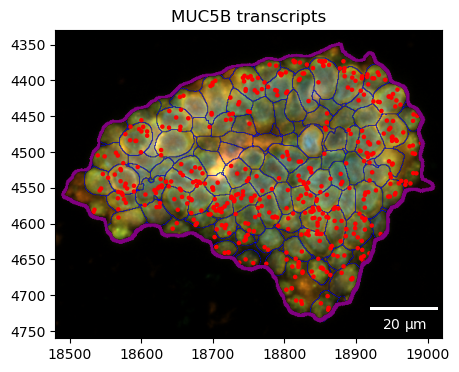

In [104]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))

um_per_px = 1.0 / get_transformation(cropped["transcripts"], "global").scale[0] 

(
    cropped
    .pl.render_images("morphology_focus")
    .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0, contour_px=3)
    .pl.render_points(groups=["MUC5B"], color="feature_name", palette="red", size=5)
    .pl.render_labels("tissue_labels", color="purple", outline_alpha=1, fill_alpha=0, contour_px=10)
    .pl.show(
        title="MUC5B transcripts", 
        legend_loc=None,
        scalebar_dx=um_per_px,  # Xenium standard
        scalebar_units="um",
        scalebar_params={
            "location": "lower right",
            "color": "white",
            "box_color": "black",
        },
        ax=ax,
    )
)
fig.savefig("../../_static/img/create_cells_dataset.png", dpi=150)

In [103]:
%load_ext watermark
%watermark -v -m -p spatialdata,spatialdata_io,spatialdata_plot,skimage,scanpy,anndata,zarr,matplotlib,pandas,numpy

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_io  : 0.7.0
spatialdata_plot: 0.3.4
skimage         : 0.26.0
scanpy          : 1.12.1
anndata         : 0.12.14
zarr            : 3.2.1
matplotlib      : 3.10.9
pandas          : 2.3.3
numpy           : 2.4.5

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.14.0-570.25.1.el9_6.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 48
Architecture: 64bit

